In [ ]:
import numpy as np
import matplotlib.pyplot as plt


from src.quantum_hrp import average_density_matrix, compute_distance_matrix
from src.hrp_ordering import hrp_order_from_distance

In [ ]:
features = np.load("../../data/features.npy")

N = features.shape[0]
alpha = 2.0

Features shape: (169, 616, 6)


In [ ]:
rhos = []
for i in range(N):
    rho = average_density_matrix(features[i], alpha=alpha)
    rhos.append(rho)

D = compute_distance_matrix(rhos)


In [5]:
print("Diagonal (min, max):", D.diagonal().min(), D.diagonal().max())
print("Symmetry check:", np.allclose(D, D.T))

Diagonal (min, max): 0.0 2.9802322387695312e-08
Symmetry check: True


In [ ]:
order_qhrp = hrp_order_from_distance(D)
D_ordered = D[np.ix_(order_qhrp, order_qhrp)]

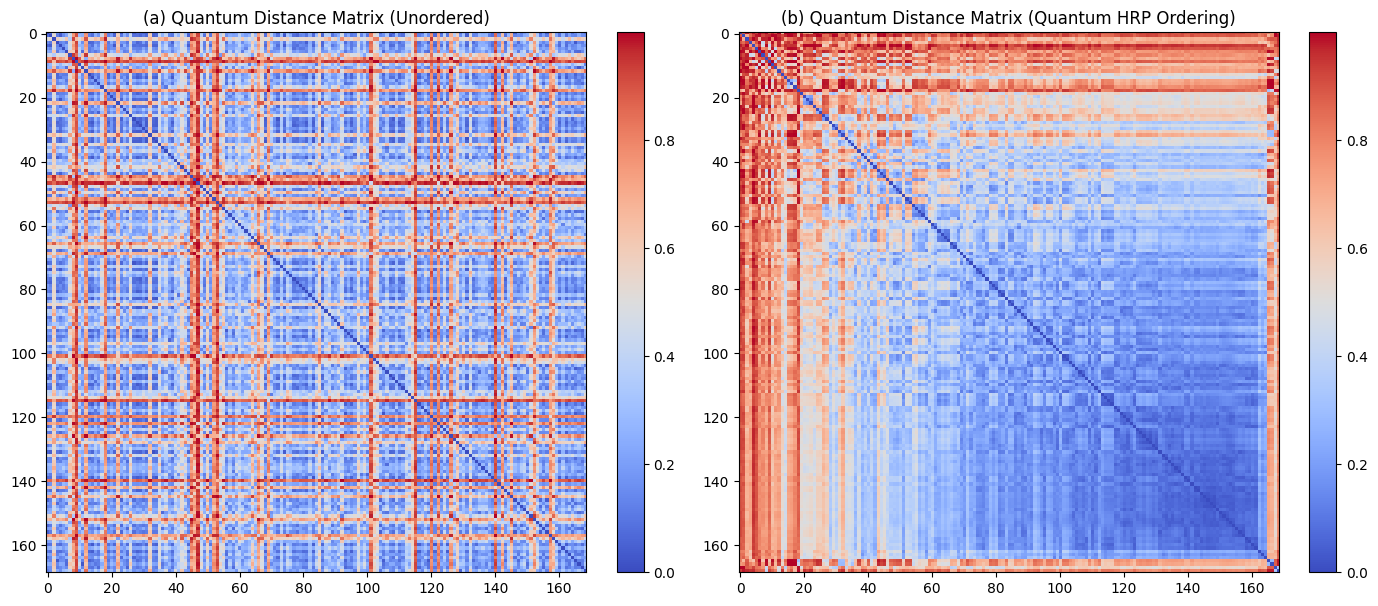

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im0 = axes[0].imshow(D, cmap="coolwarm")
axes[0].set_title("(a) Quantum Distance Matrix (Unordered)")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(D_ordered, cmap="coolwarm")
axes[1].set_title("(b) Quantum Distance Matrix (Quantum HRP Ordering)")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()